In [26]:
from sklearn import datasets
import pandas as pd
import numpy as np

iris = datasets.load_iris()

In [27]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

In [32]:
df.rename(columns={'sepal length (cm)' : 'sepal_len',
                   'sepal width (cm)' : 'sepal_width',
                   'petal length (cm)' : 'petal_len',
                   'petal width (cm)' : 'petal_width'}, inplace=True)

In [33]:
df.sample(5)

,sepal_len,sepal_width,petal_len,petal_width,species
21,5.1,3.7,1.5,0.4,0
36,5.5,3.5,1.3,0.2,0
133,6.3,2.8,5.1,1.5,2
140,6.7,3.1,5.6,2.4,2
8,4.4,2.9,1.4,0.2,0


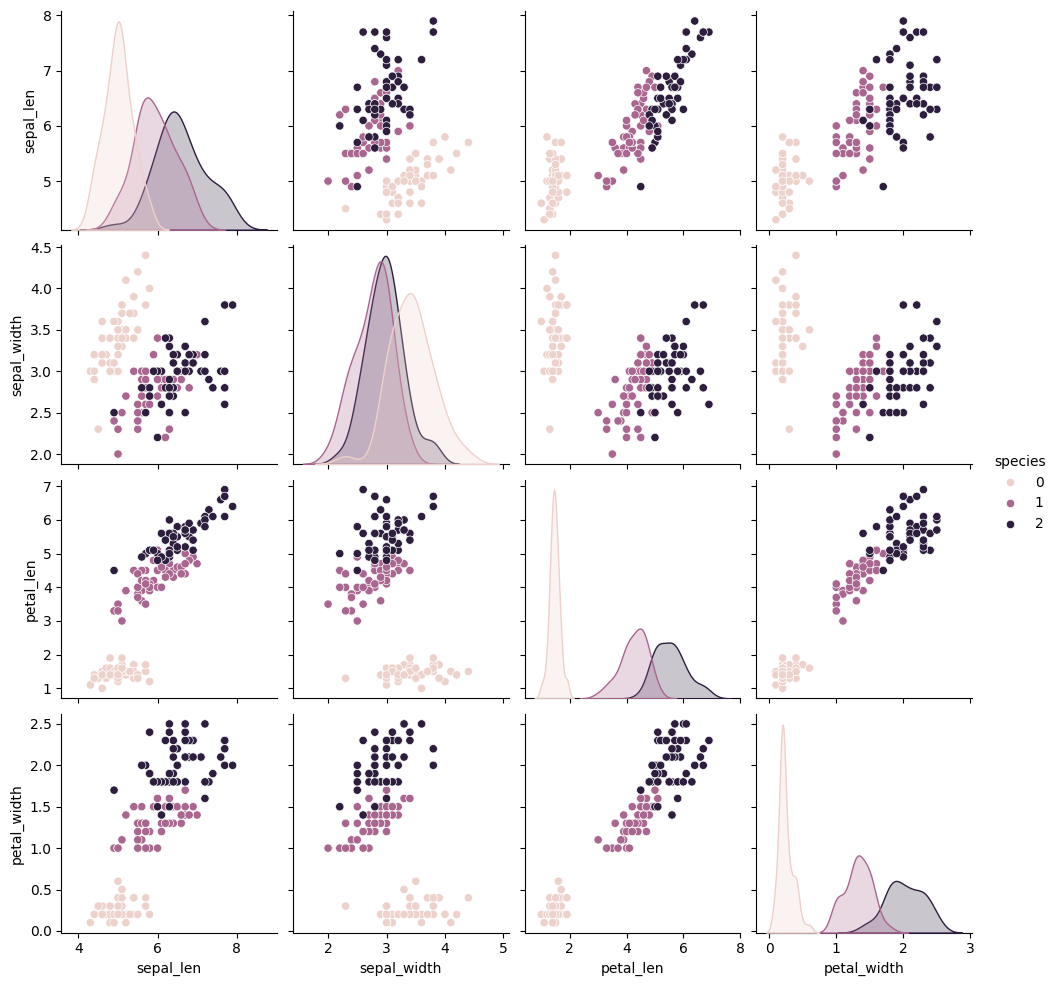

In [34]:
import seaborn as sns
sns.pairplot(df, hue='species')

In [37]:
new_df = df[df['species'] != 0][['sepal_len', 'sepal_width','species']]

In [38]:
new_df.sample(3)

,sepal_len,sepal_width,species
121,5.6,2.8,2
61,5.9,3.0,1
136,6.3,3.4,2


In [39]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [42]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [44]:
estimators = [('lor', clf1), ('rf',clf2), ('knn',clf3)]

In [45]:
for estimator in estimators:
  x = cross_val_score(estimator[1], X, y, cv = 10, scoring='accuracy')
  print(estimator[0], np.round(np.mean(x),2))

lor 0.81
rf 0.73
knn 0.76


In [46]:
from sklearn.ensemble import VotingClassifier

### Hard Voting

In [47]:
vc = VotingClassifier(estimators=estimators, voting='hard')
x=cross_val_score(vc, X, y, cv = 10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


### Soft Voting

In [48]:
vc1 = VotingClassifier(estimators=estimators, voting='soft')
x=cross_val_score(vc1, X, y, cv = 10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.76


### Weighted votinng

In [50]:
for i in range(1,4):
  for j in range(1,4):
    for k in range(1,4):
      vc = VotingClassifier(estimators=estimators, voting='soft', weights=[i,j,k])
      x=cross_val_score(vc, X, y, cv = 10, scoring='accuracy')
      print('for i={}, j={}, k={} : '.format(i,j,k),np.round(np.mean(x),2))

for i=1, j=1, k=1 :  0.75
for i=1, j=1, k=2 :  0.75
for i=1, j=1, k=3 :  0.75
for i=1, j=2, k=1 :  0.75
for i=1, j=2, k=2 :  0.75
for i=1, j=2, k=3 :  0.75
for i=1, j=3, k=1 :  0.74
for i=1, j=3, k=2 :  0.75
for i=1, j=3, k=3 :  0.75
for i=2, j=1, k=1 :  0.77
for i=2, j=1, k=2 :  0.77
for i=2, j=1, k=3 :  0.76
for i=2, j=2, k=1 :  0.76
for i=2, j=2, k=2 :  0.76
for i=2, j=2, k=3 :  0.77
for i=2, j=3, k=1 :  0.75
for i=2, j=3, k=2 :  0.75
for i=2, j=3, k=3 :  0.75
for i=3, j=1, k=1 :  0.79
for i=3, j=1, k=2 :  0.78
for i=3, j=1, k=3 :  0.78
for i=3, j=2, k=1 :  0.77
for i=3, j=2, k=2 :  0.77
for i=3, j=2, k=3 :  0.77
for i=3, j=3, k=1 :  0.77
for i=3, j=3, k=2 :  0.76
for i=3, j=3, k=3 :  0.75


### Classifier with same algo

In [53]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC

X, y = make_classification(n_samples=1000,
                           n_features=20,

                           n_redundant=5,
                           random_state=2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=1)
svm3 = SVC(probability=True, kernel='poly', degree=1)
svm4 = SVC(probability=True, kernel='poly', degree=1)
svm5 = SVC(probability=True, kernel='poly', degree=1)

estimators = [('svm1',svm1), ('svm2',svm2), ('svm3',svm3), ('svm4',svm4), ('svm5',svm5)]

for estimator in estimators:
  x=cross_val_score(vc, X, y, cv = 10, scoring='accuracy')
  print(estimator[0], np.round(np.mean(x),2))

svm1 0.89
svm2 0.89
svm3 0.88
svm4 0.89
svm5 0.88


In [55]:
vc = VotingClassifier(estimators=estimators, voting='soft')
x=cross_val_score(vc, X, y, cv = 10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.89
